<a href="https://colab.research.google.com/github/soyyoon/ML_project/blob/main/final_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 모델 학습을 위한 데이터 전처리

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import center_of_mass, shift
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
import os

# ===============================
# 0. 구글 드라이브 마운트
# ===============================
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/ML_Project'
SAVE_PATH_TRAIN = os.path.join(BASE_DIR, 'colored_mnist_train.npz')
SAVE_PATH_VAL = os.path.join(BASE_DIR, 'colored_mnist_val.npz')

# ===============================
# 1. 데이터 로드
# ===============================
train_data = np.load(SAVE_PATH_TRAIN)
X_train_color = train_data['images']
y_train_digit = train_data['labels_digit']
y_train_fg = train_data['labels_fg']
y_train_bg = train_data['labels_bg']

val_data = np.load(SAVE_PATH_VAL)
X_val_color = val_data['images']
y_val_digit = val_data['labels_digit']
y_val_fg = val_data['labels_fg']
y_val_bg = val_data['labels_bg']

print(f"Train shape: {X_train_color.shape}, Val shape: {X_val_color.shape}")


Mounted at /content/drive
Train shape: (60000, 28, 28, 3), Val shape: (10000, 28, 28, 3)


## 전처리

In [10]:
def remove_background_corner_rule(images, patch_size=2, threshold=30, bg_value=0):
    N, H, W, C = images.shape
    out = np.zeros_like(images)
    for i in tqdm(range(N), desc="BG 제거"):
        img = images[i]
        is_float = img.max() <= 1.0
        img_uint = (img * 255).astype(np.uint8) if is_float else img.astype(np.uint8)
        # 코너 평균
        tl = img_uint[0:patch_size, 0:patch_size, :]
        tr = img_uint[0:patch_size, W-patch_size:W, :]
        bl = img_uint[H-patch_size:H, 0:patch_size, :]
        br = img_uint[H-patch_size:H, W-patch_size:W, :]
        bg_color = np.mean(np.concatenate([tl.reshape(-1,3), tr.reshape(-1,3), bl.reshape(-1,3), br.reshape(-1,3)], axis=0), axis=0)
        mask_bg = np.linalg.norm(img_uint - bg_color, axis=2) < threshold
        img_uint[mask_bg] = bg_value
        out[i] = (img_uint.astype(np.float32)/255.0) if is_float else img_uint
    return out

def rgb_to_gray_max(images):
    imgs = images.astype(np.float32)/255.0 if images.max() > 1.0 else images.astype(np.float32)
    return np.max(imgs, axis=3)

def binarize(images_gray, threshold=0.5):
    return (images_gray > threshold).astype(np.float32)

def center_images_com(images, size=28):
    centered = []
    cy, cx = size / 2, size / 2
    for img in images:
        if np.sum(img) == 0:
            centered.append(img)
            continue
        com_y, com_x = center_of_mass(img)
        shifted = shift(img, shift=[cy-com_y, cx-com_x], order=0, mode='constant', cval=0)
        centered.append(shifted)
    return np.array(centered)

def extract_hog_features(images, ppc=4, cpb=2):
    feats = []
    for img in images:
        feats.append(hog(img, pixels_per_cell=(ppc,ppc), cells_per_block=(cpb,cpb), visualize=False))
    return np.array(feats, dtype=np.float32)

def extract_color_features(images_color, images_gray, threshold=0.1):
    N, H, W, C = images_color.shape
    fg_features = np.zeros((N,3), dtype=np.float32)
    bg_features = np.zeros((N,3), dtype=np.float32)
    for i in range(N):
        img = images_color[i].astype(np.float32)
        gray = images_gray[i]
        # BG: 4코너 평균
        tl, tr = img[0:2,0:2,:], img[0:2,W-2:W,:]
        bl, br = img[H-2:H,0:2,:], img[H-2:H,W-2:W,:]
        bg_features[i] = np.mean(np.concatenate([tl.reshape(-1,3), tr.reshape(-1,3), bl.reshape(-1,3), br.reshape(-1,3)], axis=0), axis=0)
        # FG: 숫자 영역
        mask = gray > threshold
        fg_features[i] = np.mean(img[mask], axis=0) if np.sum(mask)>0 else bg_features[i]
    return fg_features, bg_features

## 전처리 적용

In [11]:
X_train_nobg = remove_background_corner_rule(X_train_color)
X_val_nobg = remove_background_corner_rule(X_val_color)

X_train_gray = rgb_to_gray_max(X_train_nobg)
X_val_gray = rgb_to_gray_max(X_val_nobg)

X_train_bin = binarize(X_train_gray)
X_val_bin = binarize(X_val_gray)

X_train_centered = center_images_com(X_train_bin)
X_val_centered = center_images_com(X_val_bin)

X_train_hog = extract_hog_features(X_train_centered)
X_val_hog = extract_hog_features(X_val_centered)

X_train_fg, X_train_bg = extract_color_features(X_train_color, X_train_gray)
X_val_fg, X_val_bg = extract_color_features(X_val_color, X_val_gray)

BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 8189.26it/s]


## 학습

In [19]:
models = {
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

trained_models = {}

for task_name, X_tr, y_tr in zip(
    ["Digit(HOG)", "FG Color", "BG Color"],
    [X_train_hog, X_train_fg, X_train_bg],
    [y_train_digit, y_train_fg, y_train_bg]
):
    trained_models[task_name] = {}
    for model_name, model_class in models.items():
        print(f"\nTraining {model_name} for {task_name}...")
        # 각 task마다 새로운 모델 인스턴스 생성
        if model_name == "RandomForest":
            model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        elif model_name == "XGBoost":
            model = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
        elif model_name == "LightGBM":
            model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)

        model.fit(X_tr, y_tr)
        trained_models[task_name][model_name] = model
        print(f"  -> {model_name} trained on {X_tr.shape[0]} samples with {X_tr.shape[1]} features")


Training RandomForest for Digit(HOG)...
  -> RandomForest trained on 60000 samples with 1296 features

Training XGBoost for Digit(HOG)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:46:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  -> XGBoost trained on 60000 samples with 1296 features

Training LightGBM for Digit(HOG)...
  -> LightGBM trained on 60000 samples with 1296 features

Training RandomForest for FG Color...
  -> RandomForest trained on 60000 samples with 3 features

Training XGBoost for FG Color...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:58:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  -> XGBoost trained on 60000 samples with 3 features

Training LightGBM for FG Color...
  -> LightGBM trained on 60000 samples with 3 features

Training RandomForest for BG Color...
  -> RandomForest trained on 60000 samples with 3 features

Training XGBoost for BG Color...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:58:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  -> XGBoost trained on 60000 samples with 3 features

Training LightGBM for BG Color...
  -> LightGBM trained on 60000 samples with 3 features



=== Validation: colored_mnist_val.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 8339.14it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 98.8800%, AUC = 0.9998145582644478


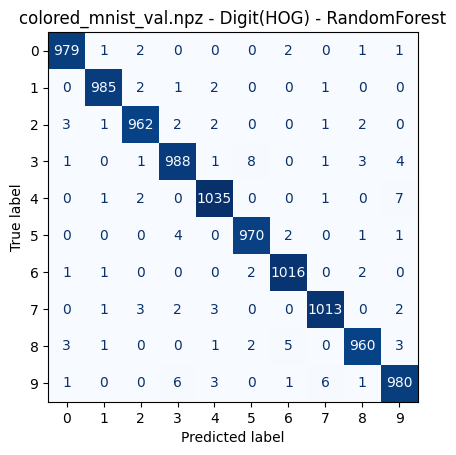

XGBoost         : Accuracy = 99.0700%, AUC = 0.9999110505814253


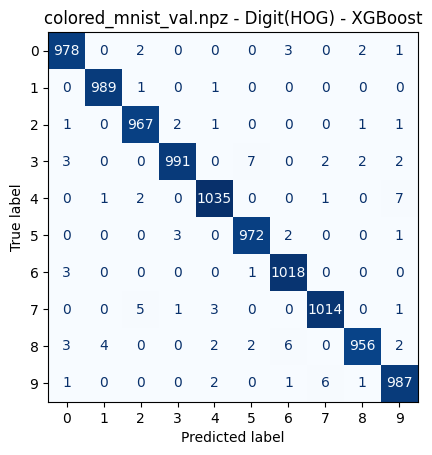

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.1300%, AUC = 0.9999073961091608


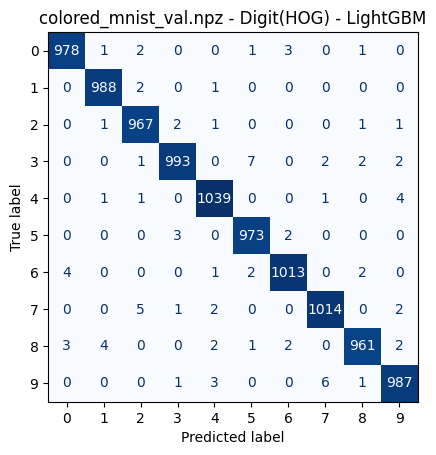


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


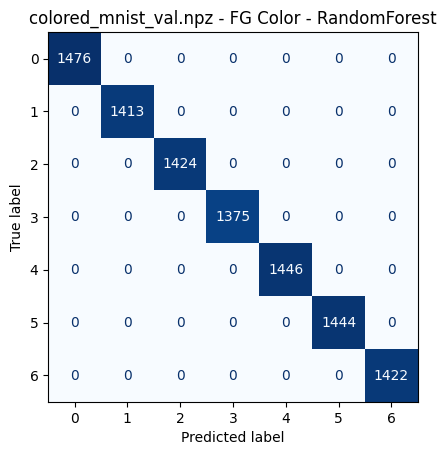

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


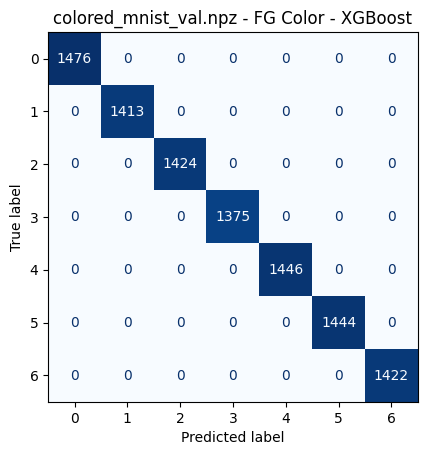

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


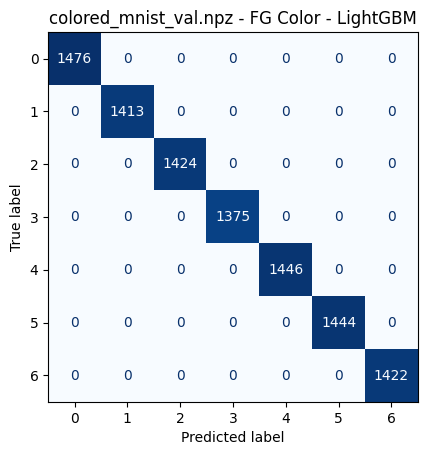


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


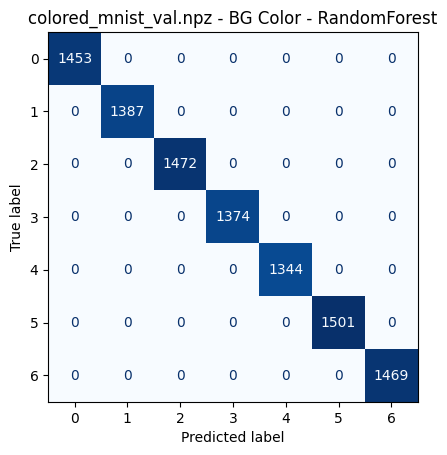

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


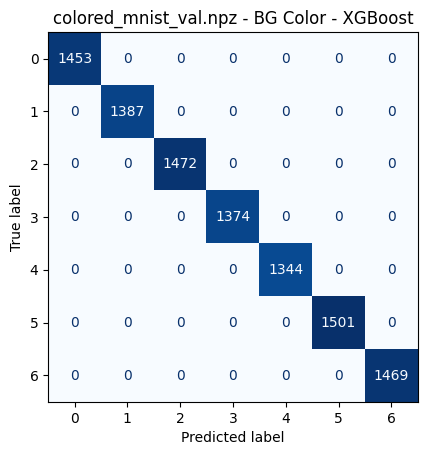

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


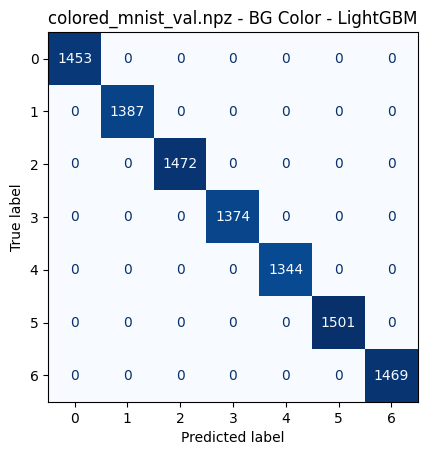


=== Validation: colored_mnist_valid_all.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 8436.11it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 94.2900%, AUC = 0.9947112231135333


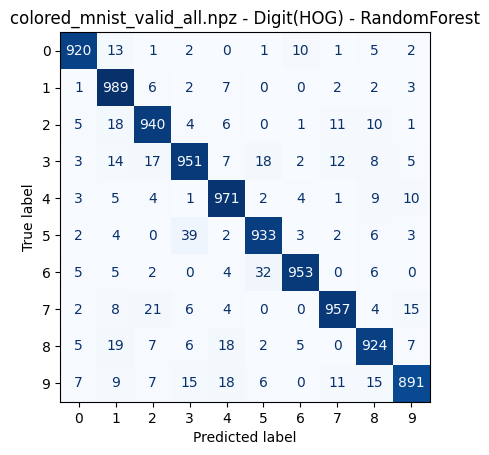

XGBoost         : Accuracy = 94.7800%, AUC = 0.9977033705609729


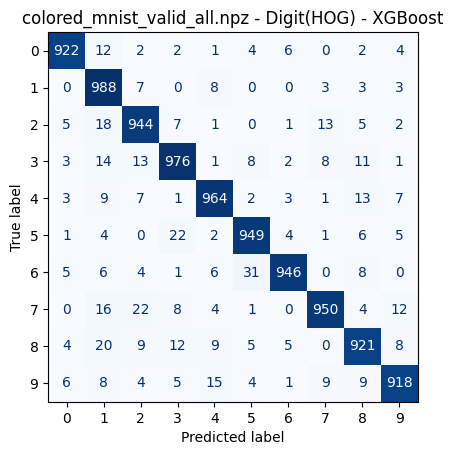

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 94.8700%, AUC = 0.9977506404567477


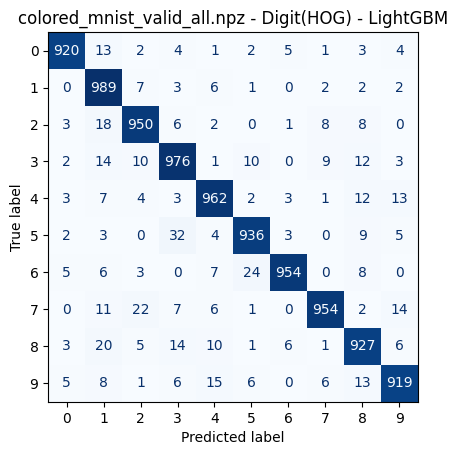


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 99.1900%, AUC = 0.9956364453711128


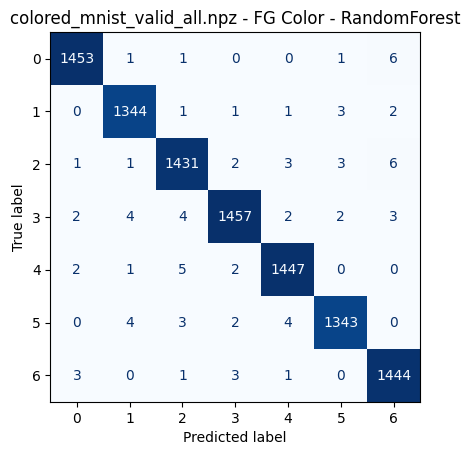

XGBoost         : Accuracy = 99.2100%, AUC = 0.9996920513432362


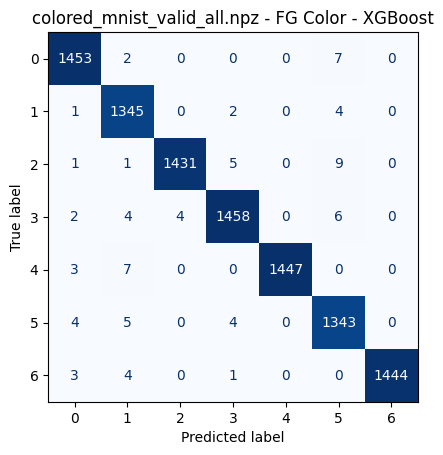

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.2300%, AUC = 0.9968578847296432


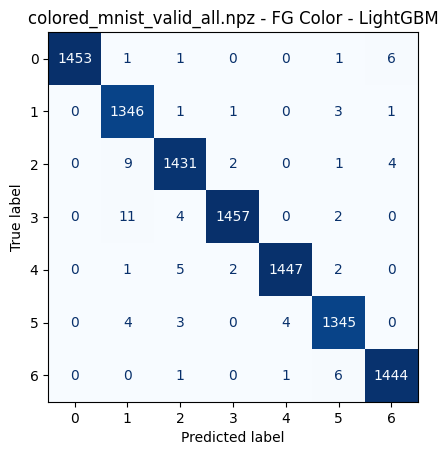


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 99.9000%, AUC = 0.9998913678749816


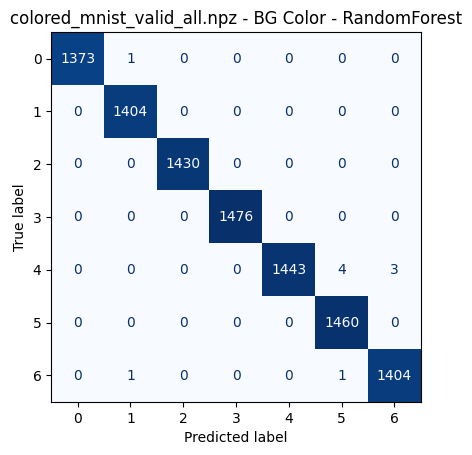

XGBoost         : Accuracy = 99.0200%, AUC = 0.9986477360329808


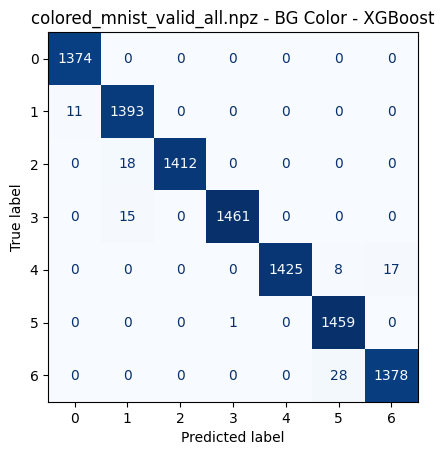

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.5600%, AUC = 0.9997806176844886


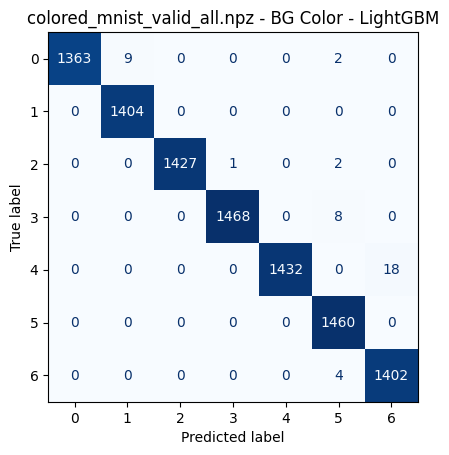


=== Validation: colored_mnist_valid_rotate.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 5995.91it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 97.0600%, AUC = 0.9990000005903725


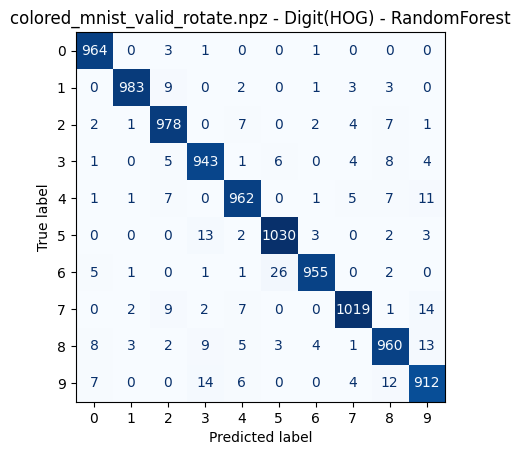

XGBoost         : Accuracy = 97.4400%, AUC = 0.999451904195106


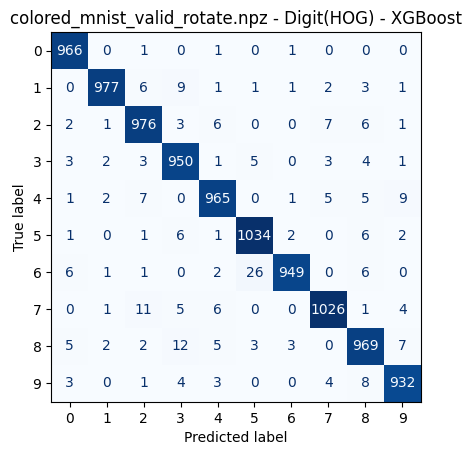

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 97.3100%, AUC = 0.9994403055783613


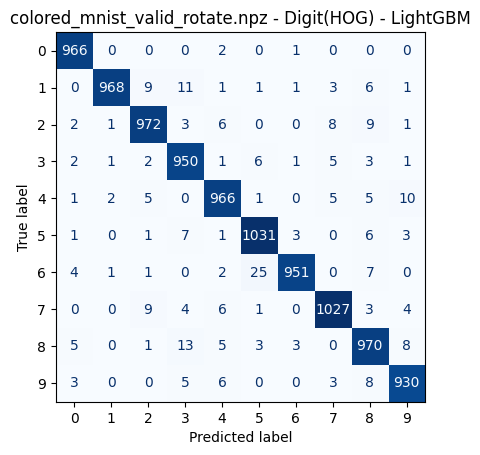


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


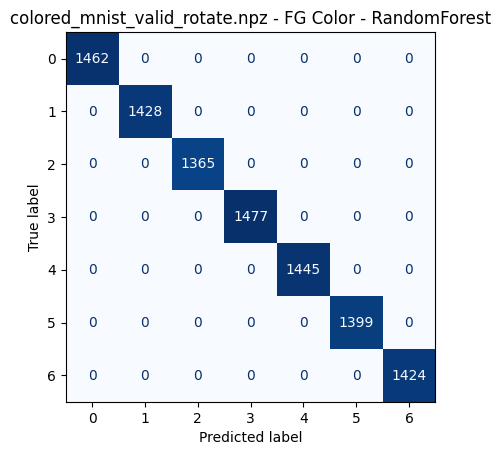

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


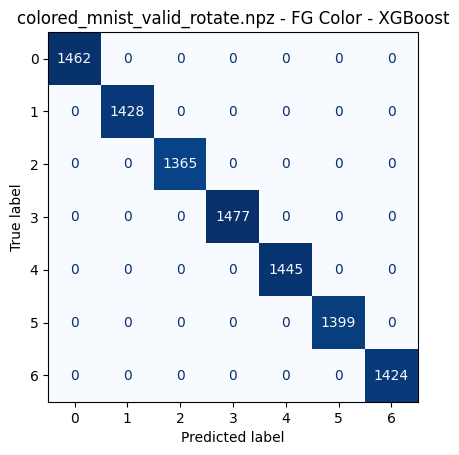

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


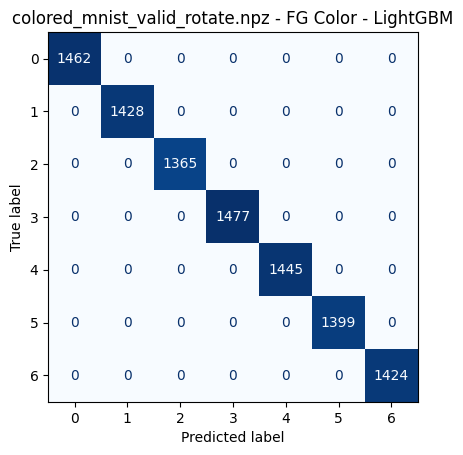


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


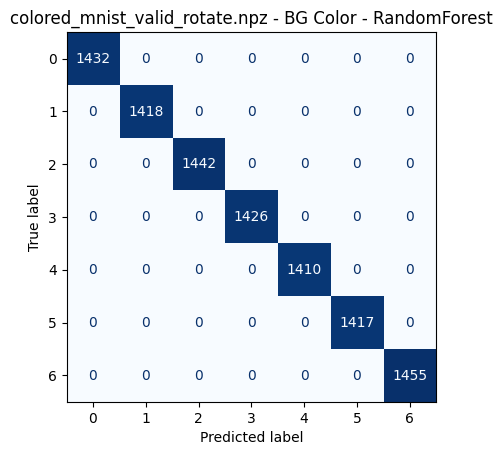

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


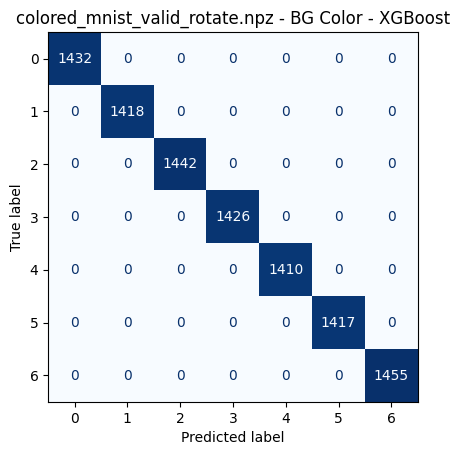

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


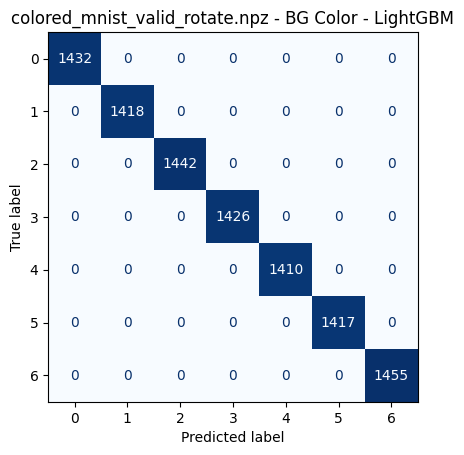


=== Validation: colored_mnist_valid_scale.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 7657.90it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 96.8700%, AUC = 0.9990365268720625


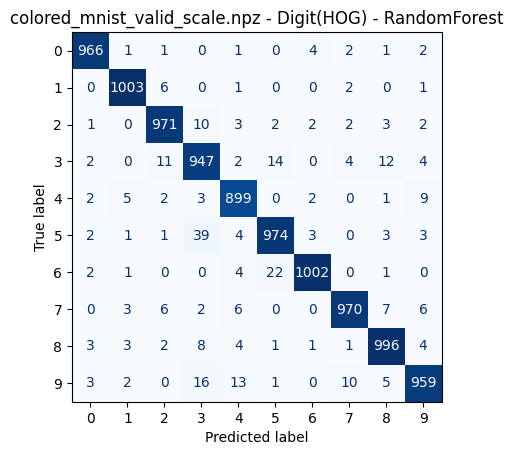

XGBoost         : Accuracy = 97.4500%, AUC = 0.9995553561933229


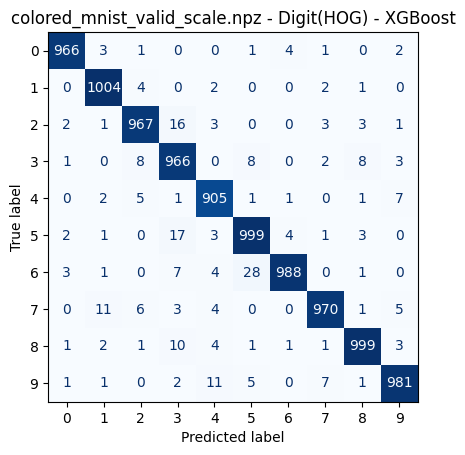

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 97.5300%, AUC = 0.9995132962657928


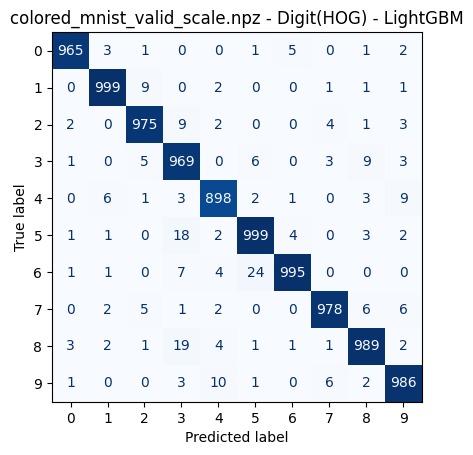


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 99.9900%, AUC = 0.99995


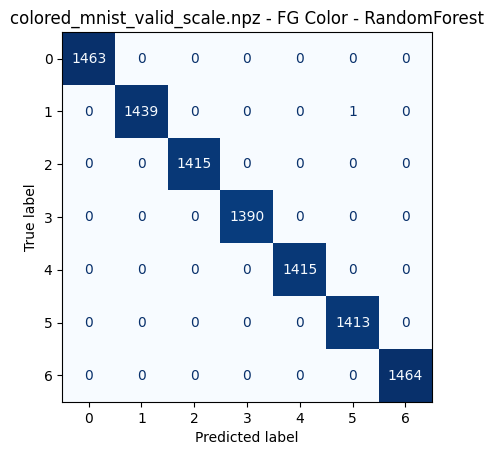

XGBoost         : Accuracy = 99.9800%, AUC = 0.9999648484722631


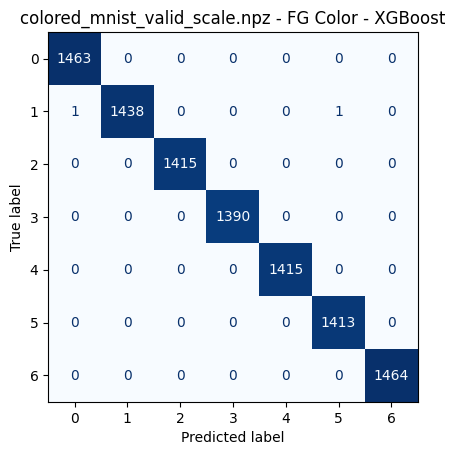

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


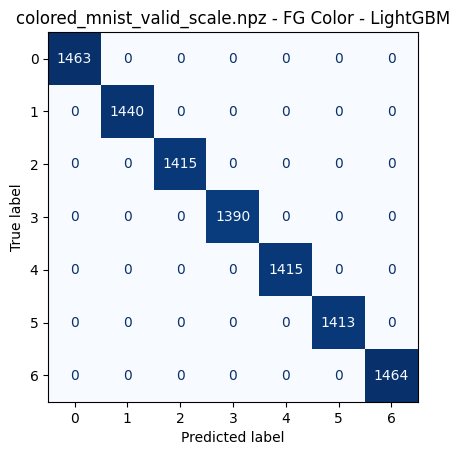


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


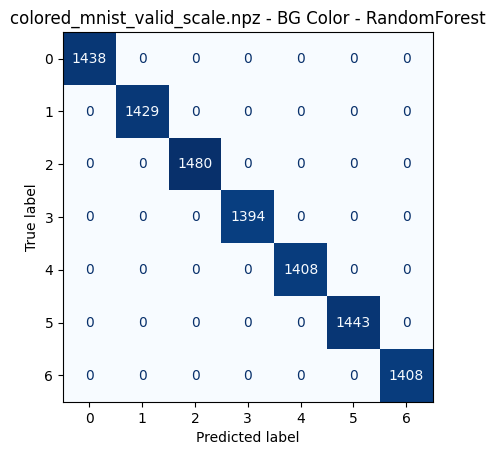

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


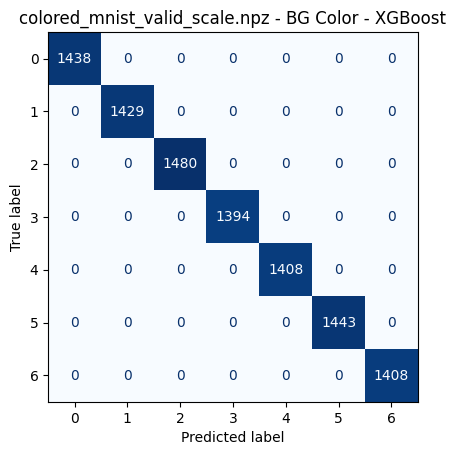

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


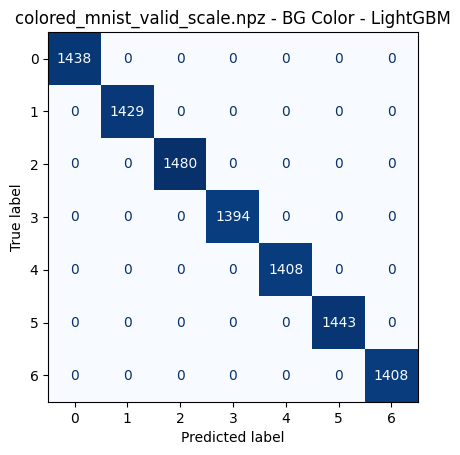


=== Validation: colored_mnist_valid_shear.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:02<00:00, 4878.21it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 97.9500%, AUC = 0.999552755901767


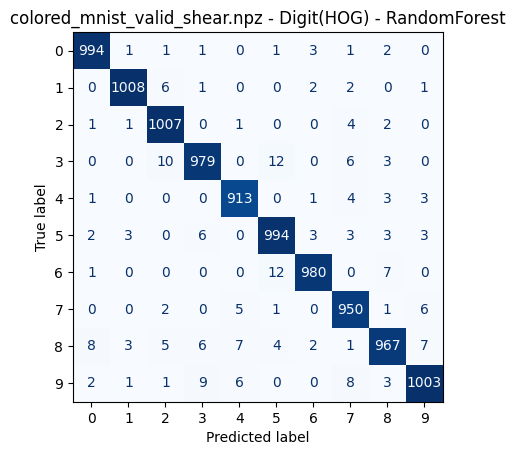

XGBoost         : Accuracy = 98.4000%, AUC = 0.9998366940783794


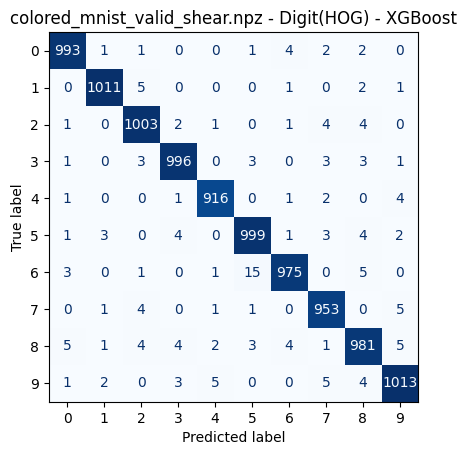

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 98.3700%, AUC = 0.9998244381470136


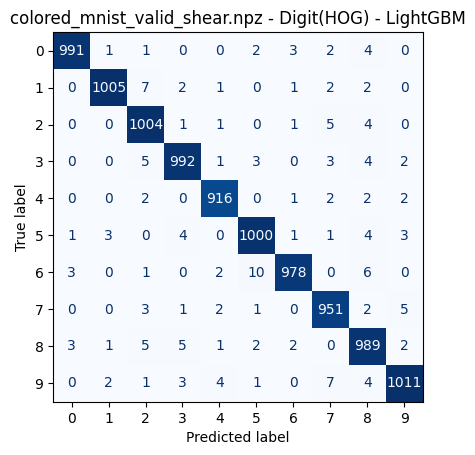


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


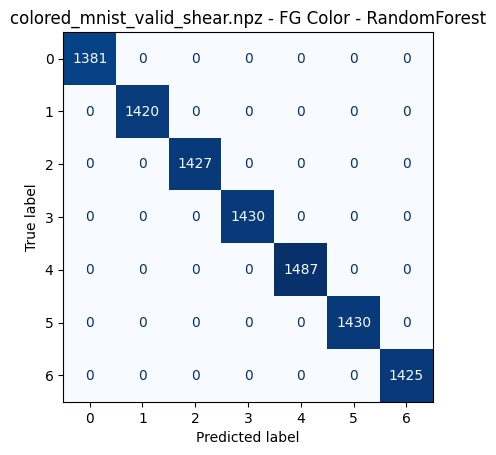

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


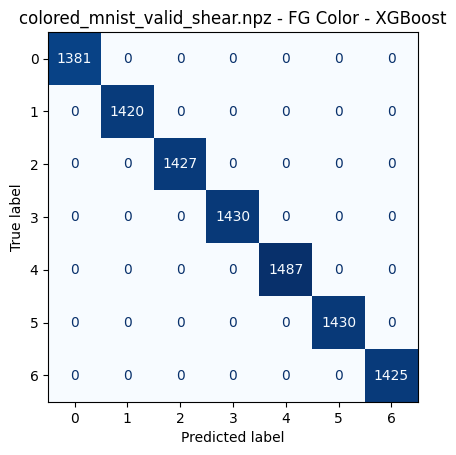

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


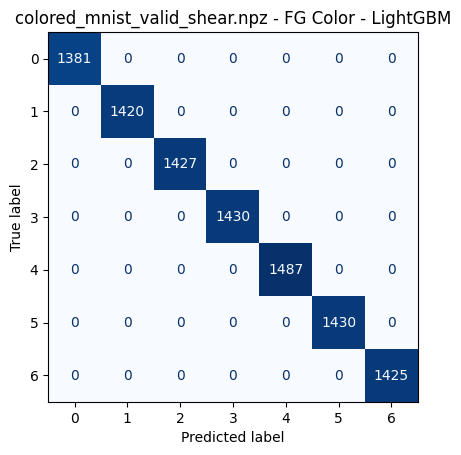


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 100.0000%, AUC = 1.0


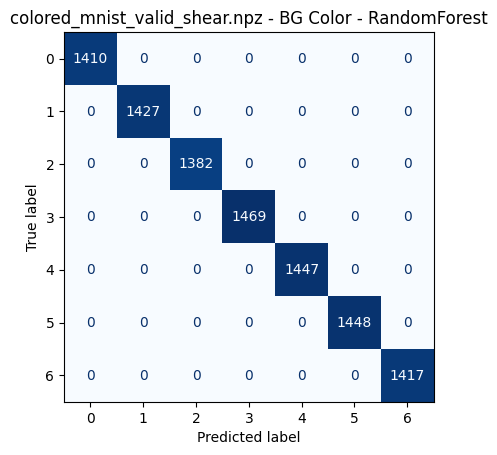

XGBoost         : Accuracy = 100.0000%, AUC = 1.0


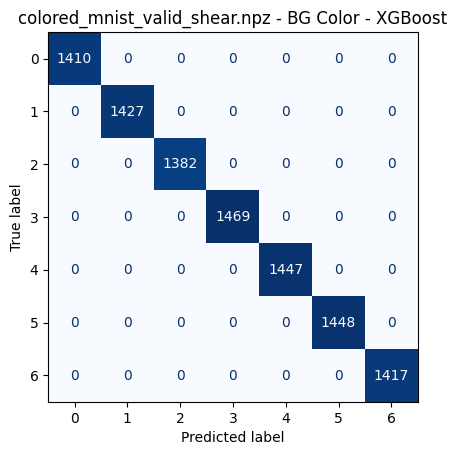

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 100.0000%, AUC = 1.0


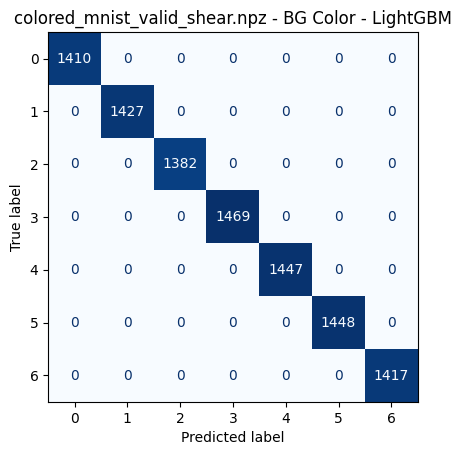


=== Validation: colored_mnist_valid_shift.npz ===


BG 제거: 100%|██████████| 10000/10000 [00:01<00:00, 7616.48it/s]



--------------------------------------------------
-- Task: Digit(HOG) --
--------------------------------------------------
Test features shape: (10000, 1296)
RandomForest    : Accuracy = 98.7900%, AUC = 0.9998403443438767


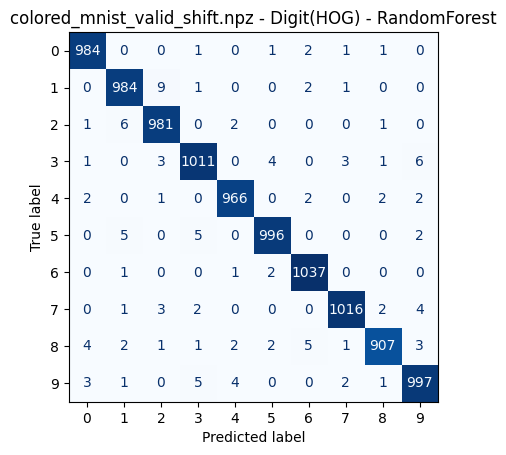

XGBoost         : Accuracy = 99.0300%, AUC = 0.9999256908610611


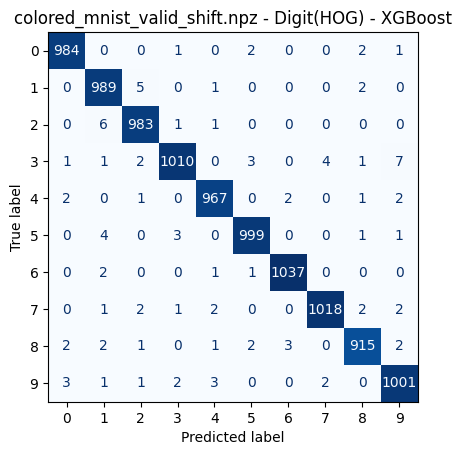

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.0200%, AUC = 0.999920408771363


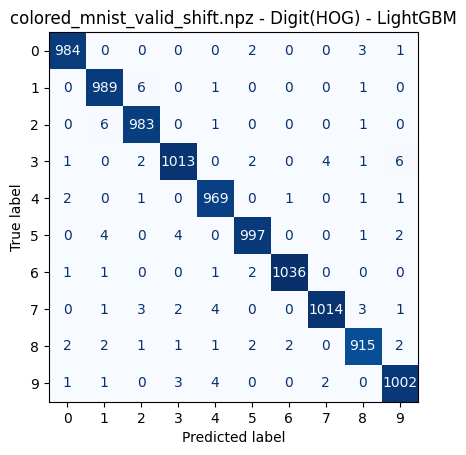


--------------------------------------------------
-- Task: FG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 99.8800%, AUC = 0.9993674710184861


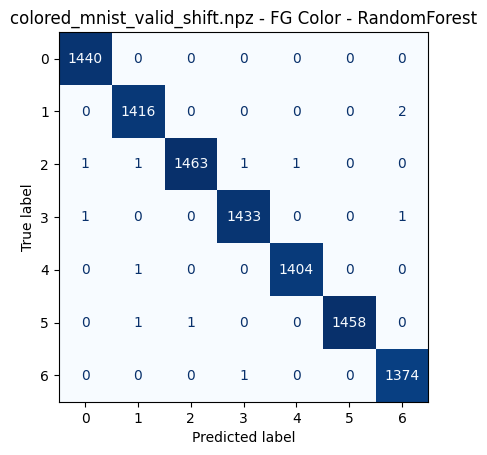

XGBoost         : Accuracy = 99.8800%, AUC = 0.9998643324240732


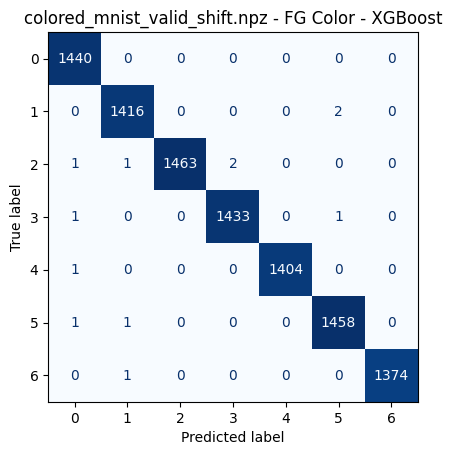

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.8800%, AUC = 0.9995062937039669


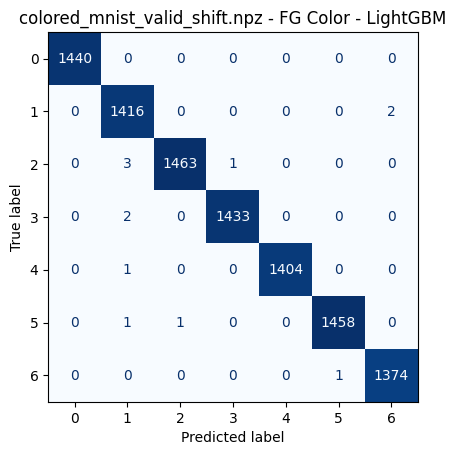


--------------------------------------------------
-- Task: BG Color --
--------------------------------------------------
Test features shape: (10000, 3)
RandomForest    : Accuracy = 99.9800%, AUC = 0.9998920558581527


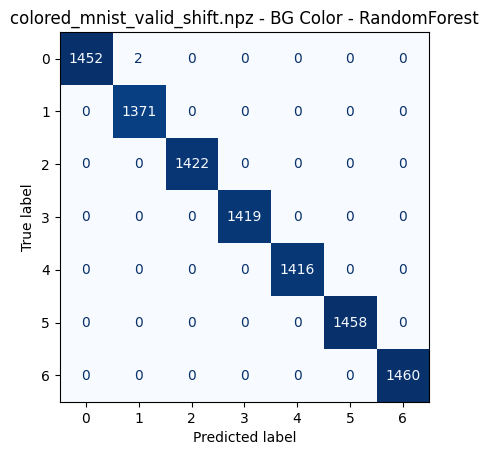

XGBoost         : Accuracy = 99.8000%, AUC = 0.9997161988524603


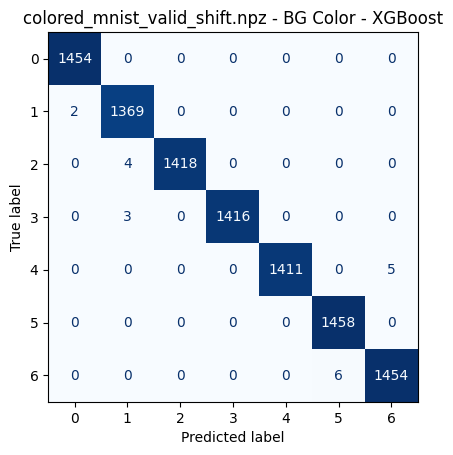

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM        : Accuracy = 99.9300%, AUC = 0.9999680108932806


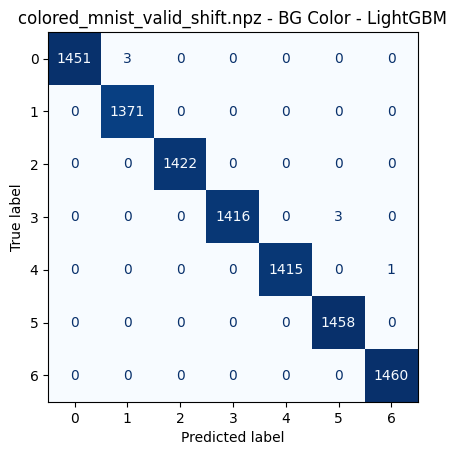

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

VALID_FILES = [
    "colored_mnist_val.npz",
    "colored_mnist_valid_all.npz",
    "colored_mnist_valid_rotate.npz",
    "colored_mnist_valid_scale.npz",
    "colored_mnist_valid_shear.npz",
    "colored_mnist_valid_shift.npz"
]

for valid_file in VALID_FILES:
    print(f"\n{'='*60}")
    print(f"=== Validation: {valid_file} ===")
    print(f"{'='*60}")
    path = os.path.join(BASE_DIR, valid_file)
    val_data = np.load(path)
    X_val_color = val_data['images']
    y_val_digit = val_data['labels_digit']
    y_val_fg = val_data['labels_fg']
    y_val_bg = val_data['labels_bg']

    # 숫자 전처리
    X_val_nobg = remove_background_corner_rule(X_val_color)
    X_val_gray = rgb_to_gray_max(X_val_nobg)
    X_val_bin = binarize(X_val_gray)
    X_val_centered = center_images_com(X_val_bin)
    X_val_hog = extract_hog_features(X_val_centered)

    # 색상 특징
    X_val_fg, X_val_bg = extract_color_features(X_val_color, X_val_gray)

    # 데이터 딕셔너리
    X_val_dict = {
        "Digit(HOG)": X_val_hog,
        "FG Color": X_val_fg,
        "BG Color": X_val_bg
    }
    y_val_dict = {
        "Digit(HOG)": y_val_digit,
        "FG Color": y_val_fg,
        "BG Color": y_val_bg
    }

    for task in ["Digit(HOG)", "FG Color", "BG Color"]:
        print(f"\n{'-'*50}")
        print(f"-- Task: {task} --")
        print(f"{'-'*50}")
        X_te = X_val_dict[task]
        y_te = y_val_dict[task]

        print(f"Test features shape: {X_te.shape}")

        for model_name, model in trained_models[task].items():
            # 예측
            y_pred = model.predict(X_te)

            # Accuracy
            acc = accuracy_score(y_te, y_pred)

            # AUC (multi-class 안전하게)
            try:
                y_proba = model.predict_proba(X_te)
                y_te_bin = label_binarize(y_te, classes=np.arange(y_proba.shape[1]))
                auc = roc_auc_score(y_te_bin, y_proba, multi_class='ovr', average='weighted')
            except:
                auc = 'N/A'

            print(f"{model_name:<15} : Accuracy = {acc:.4%}, AUC = {auc}")

            cm = confusion_matrix(y_te, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(cmap='Blues', colorbar=False)
            plt.title(f"{valid_file} - {task} - {model_name}")
            plt.show()